Sample EDA for Subreddit Data

In [147]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
BASE_DIR = Path.cwd()

file_path = BASE_DIR / "uktravel_submissions.csv"

print("File location:", file_path)
print("File exists:", file_path.exists())

df = pd.read_csv(file_path)
df.head()

File location: c:\Users\myq14\CSE 6748 Project\subreddits25\travel_submissions.csv
File exists: True


,author,title,ups,downs,score,num_comments,num_crossposts,num_reports,created_utc,permalink,selftext,url,id,subreddit,subreddit_subscribers,upvote_ratio
0,u/supbri22,MoMA vs the Ride NYC,1.0,0.0,1,10,0,0.0,2024-01-01 05:01,/r/travel/comments/18vki2e/moma_vs_the_ride_nyc/,"Hi guys, I’m planning to go to nyc with some f...",https://www.reddit.com/r/travel/comments/18vki...,18vki2e,travel,9112740,1.0
1,u/geemuZ,Stolen Belongings from Benito Juarez (MEX),1.0,0.0,1,5,0,0.0,2024-01-01 05:02,/r/travel/comments/18vkiw4/stolen_belongings_f...,I left Mexico City this morning and arrived to...,https://www.reddit.com/r/travel/comments/18vki...,18vkiw4,travel,9112744,1.0
2,u/Foxsage28,Good out of U.S. locations for chill bachelor ...,1.0,0.0,1,0,0,0.0,2024-01-01 05:05,/r/travel/comments/18vkkvp/good_out_of_us_loca...,[removed],https://www.reddit.com/r/travel/comments/18vkk...,18vkkvp,travel,9112757,1.0
3,u/vudupulz,Best 5 day period for Salar de Uyuni mirror ef...,1.0,0.0,1,0,0,0.0,2024-01-01 05:10,/r/travel/comments/18vknm1/best_5_day_period_f...,If I want to maximize my chances of seeing the...,https://www.reddit.com/r/travel/comments/18vkn...,18vknm1,travel,9112779,1.0
4,u/OwnPractice5399,Best Lesser-Known Caribbean Island for a Beach...,1.0,0.0,1,0,0,0.0,2024-01-01 05:14,/r/travel/comments/18vkqor/best_lesserknown_ca...,[removed],https://www.reddit.com/r/travel/comments/18vkq...,18vkqor,travel,9121643,1.0


In [149]:
print(df.dtypes)

author                    object
title                     object
ups                      float64
downs                    float64
score                      int64
num_comments               int64
num_crossposts             int64
num_reports              float64
created_utc               object
permalink                 object
selftext                  object
url                       object
id                        object
subreddit                 object
subreddit_subscribers      int64
upvote_ratio             float64
dtype: object


In [150]:
df = df.dropna(axis=1, how='all')
numeric_cols = [
    'ups','downs','score','num_comments',
    'num_crossposts','num_reports',
    'subreddit_subscribers','upvote_ratio'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [151]:
df[numeric_cols].isnull().sum()

ups                       5
downs                    51
score                     0
num_comments              0
num_crossposts            0
num_reports              51
subreddit_subscribers     0
upvote_ratio              0
dtype: int64

In [152]:
df[numeric_cols] = df[numeric_cols].fillna(0)

In [153]:
df['created_date'] = pd.to_datetime(df['created_utc'], errors='coerce')

In [154]:
df['year'] = df['created_date'].dt.year
df['month'] = df['created_date'].dt.to_period('M')
df['week'] = df['created_date'].dt.isocalendar().week
df['day'] = df['created_date'].dt.date

In [155]:
df['title'] = df['title'].fillna('')
df['selftext'] = df['selftext'].fillna('')

df['text'] = df['title'].str.strip() + " " + df['selftext'].str.strip()
df['text'] = df['text'].str.strip()

In [156]:
df.head()

,author,title,ups,downs,score,num_comments,num_crossposts,num_reports,created_utc,permalink,...,id,subreddit,subreddit_subscribers,upvote_ratio,created_date,year,month,week,day,text
0,u/supbri22,MoMA vs the Ride NYC,1.0,0.0,1,10,0,0.0,2024-01-01 05:01,/r/travel/comments/18vki2e/moma_vs_the_ride_nyc/,...,18vki2e,travel,9112740,1.0,2024-01-01 05:01:00,2024,2024-01,1,2024-01-01,"MoMA vs the Ride NYC Hi guys, I’m planning to ..."
1,u/geemuZ,Stolen Belongings from Benito Juarez (MEX),1.0,0.0,1,5,0,0.0,2024-01-01 05:02,/r/travel/comments/18vkiw4/stolen_belongings_f...,...,18vkiw4,travel,9112744,1.0,2024-01-01 05:02:00,2024,2024-01,1,2024-01-01,Stolen Belongings from Benito Juarez (MEX) I l...
2,u/Foxsage28,Good out of U.S. locations for chill bachelor ...,1.0,0.0,1,0,0,0.0,2024-01-01 05:05,/r/travel/comments/18vkkvp/good_out_of_us_loca...,...,18vkkvp,travel,9112757,1.0,2024-01-01 05:05:00,2024,2024-01,1,2024-01-01,Good out of U.S. locations for chill bachelor ...
3,u/vudupulz,Best 5 day period for Salar de Uyuni mirror ef...,1.0,0.0,1,0,0,0.0,2024-01-01 05:10,/r/travel/comments/18vknm1/best_5_day_period_f...,...,18vknm1,travel,9112779,1.0,2024-01-01 05:10:00,2024,2024-01,1,2024-01-01,Best 5 day period for Salar de Uyuni mirror ef...
4,u/OwnPractice5399,Best Lesser-Known Caribbean Island for a Beach...,1.0,0.0,1,0,0,0.0,2024-01-01 05:14,/r/travel/comments/18vkqor/best_lesserknown_ca...,...,18vkqor,travel,9121643,1.0,2024-01-01 05:14:00,2024,2024-01,1,2024-01-01,Best Lesser-Known Caribbean Island for a Beach...


In [157]:
print("Total Posts:", len(df))
print("Date Range:", df['created_date'].min(), "to", df['created_date'].max())

Total Posts: 364101
Date Range: 2024-01-01 05:01:00 to 2026-01-01 04:57:00


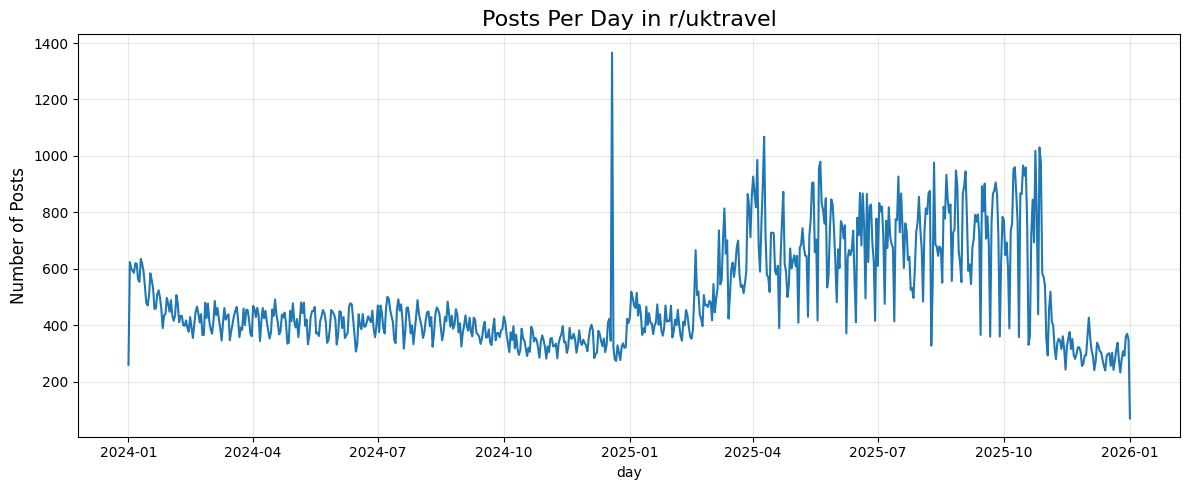

In [158]:
posts_per_day = df.groupby('day').size()
posts_per_day.plot(figsize=(12,5))
plt.title("Posts Per Day in r/uktravel", fontsize=16)
plt.ylabel("Number of Posts", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

<Axes: >

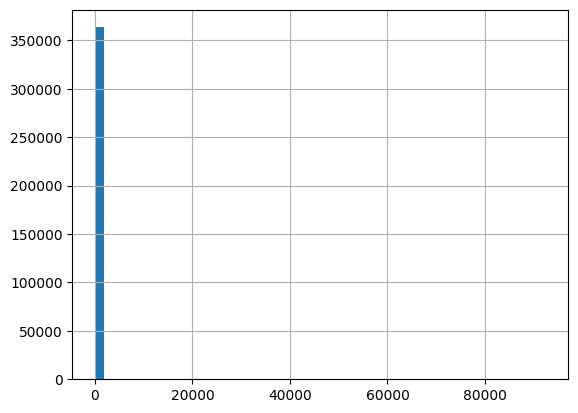

In [159]:
df['score'].describe()
df['score'].hist(bins=50)

In [160]:
df['score'].skew()

np.float64(140.49985917413483)

In [161]:
threshold = df['score'].quantile(0.95)
viral = df[df['score'] >= threshold]

print("Viral posts:", len(viral))

Viral posts: 23026


In [162]:
viral[['title','score','num_comments']].sort_values(by='score', ascending=False).head(10)

,title,score,num_comments
117605,I cycled across Mongolia. Here are some pics.,92467,1119
196034,i went on a solo trip thinking i’d “find mysel...,49373,1712
347925,A glimpse of Uzbekistan,29160,472
150583,Every seat i sat in on my journey from Europe ...,25540,494
274486,The colors of Norway (with absolutely no filters),24367,356
349901,Just Spent 3 Weeks in Egypt. I’m Never Coming ...,22064,818
354011,I feel morally obligated to warn you about Tun...,20966,608
344774,My first time in China. I am blown away.,19928,347
247149,"I visited Pyongyang, North Korea as a tourist.",19243,117
335736,"3 weeks traveling around Oman, my new favorite...",16650,572


In [163]:
df['engagement'] = (
    df['score'] +
    df['num_comments'] * 2 +
    df['num_crossposts'] * 3
)


In [164]:
df['engagement'].describe()

count    364101.000000
mean         25.365981
std         310.642039
min           0.000000
25%           1.000000
50%           3.000000
75%           6.000000
max       94735.000000
Name: engagement, dtype: float64

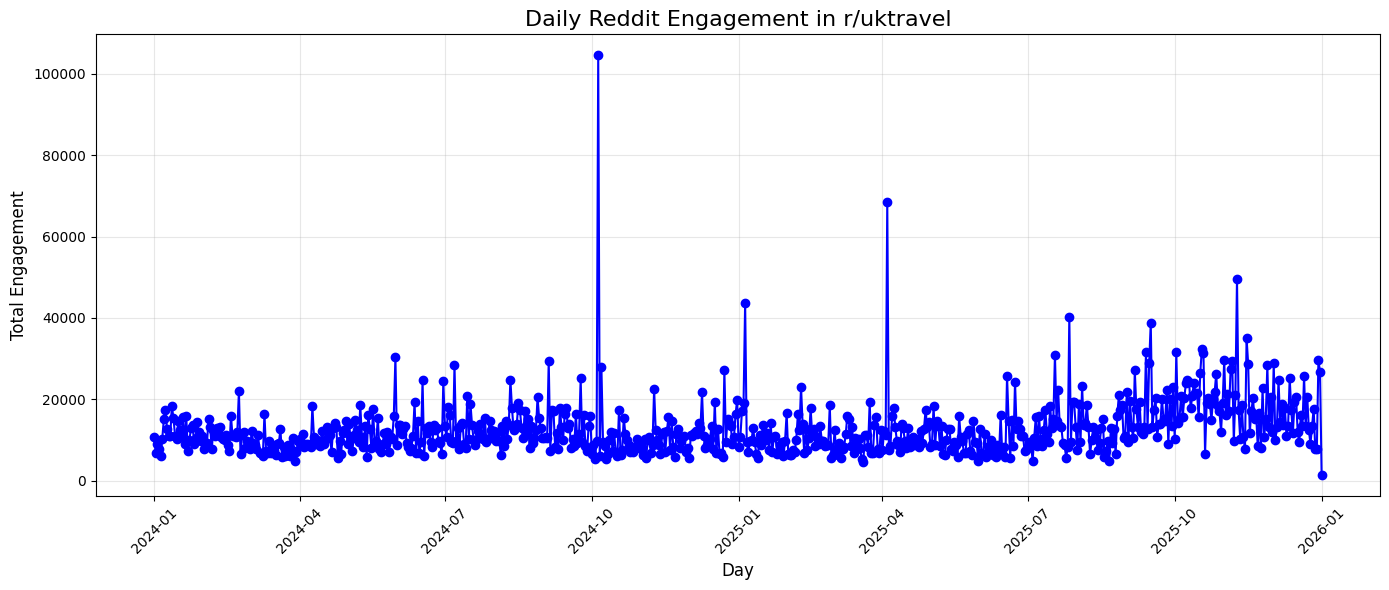

In [165]:
# Aggregate engagement per day
daily_engagement = df.groupby('day')['engagement'].sum()

# Plot
plt.figure(figsize=(14,6))
plt.plot(daily_engagement.index, daily_engagement.values, marker='o', linestyle='-', color='blue')
plt.title('Daily Reddit Engagement in r/uktravel', fontsize=16)
plt.xlabel('Day', fontsize=12)
plt.ylabel('Total Engagement', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [166]:
df2 = df.copy()

columns_to_keep = [
    'id',
    'created_date',
    'year',
    'month',
    'day',
    'subreddit',
    'title',
    'selftext',
    'text',
    # 'score',
    # 'num_comments',
    # 'num_crossposts',
    'engagement'
]

#removing some of the columns fornow since engagement wil be the main metric ill use


df2 = df2[columns_to_keep]
df2.head()
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364101 entries, 0 to 364100
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            364101 non-null  object        
 1   created_date  364101 non-null  datetime64[ns]
 2   year          364101 non-null  int32         
 3   month         364101 non-null  period[M]     
 4   day           364101 non-null  object        
 5   subreddit     364101 non-null  object        
 6   title         364101 non-null  object        
 7   selftext      364101 non-null  object        
 8   text          364101 non-null  object        
 9   engagement    364101 non-null  int64         
dtypes: datetime64[ns](1), int32(1), int64(1), object(6), period[M](1)
memory usage: 26.4+ MB


In [ ]:
df2.to_csv("test.csv", index=False)